In [ ]:
%pip install scrubadub

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras import preprocessing, models
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from tqdm import tqdm
import tensorflow.keras.utils as ku 
from keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import math
import nltk
import scrubadub
from nltk.corpus import stopwords
from sklearn.metrics import multilabel_confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import seaborn as sns
import pickle

In [ ]:
# Import necessary libraries
from pyspark.sql import SparkSession
import pandas as pd

# Set up Spark session
spark = SparkSession.builder \
    .appName("Verbatims") \
    .getOrCreate()

# Define path to your data in Azure Data Lake Storage
data_path = " - Verbatim and Topics v2.xlsx"

# Load data into a Spark DataFrame
df = spark.read.format("com.crealytics.spark.excel").option("header", "true").load(data_path)

# Load Spark DF to Pandas DF
pandas_df = df.toPandas()

display(pandas_df)

df = pandas_df.copy()  # create a copy to avoid modifying the original DataFrame

df.columns = ['o_comment', 'topic']

In [ ]:
# Make sure 'driverList' is split correctly
df['driverList'] = df['topic'].apply(lambda x: [d.strip() for d in x.split(',')])

# Create sorted list of unique topics
topics = sorted({driver for sublist in df['driverList'] for driver in sublist})
print("Unique topics detected:", topics)

# One-hot encode properly
for driver in topics:
    df[f'is{driver.replace(" ", "")}'] = df['driverList'].apply(lambda x: 1 if driver in x else 0)

# Check visually:
print(df[[f'is{topic.replace(" ", "")}' for topic in topics]].sum())

Unique topics detected: ['Customer Service', 'Digital', 'Online Experience', 'Outages and Faults', 'Process', 'Reputation', 'Sustainability', 'Trust', 'Value for Money', 'Vulnerability & FDV']
isCustomerService      6828
isDigital               793
isOnlineExperience      603
isOutagesandFaults     2019
isProcess               433
isReputation             35
isSustainability          6
isTrust                 514
isValueforMoney        1958
isVulnerability&FDV      51
dtype: int64


In [ ]:
# Implementing stopwords
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))
custom_stop_words = {'water'}
stop_words = stopwords.union(custom_stop_words)

def preprocess_text(text):
    text = text.lower().strip()  # lowercasing and stripping whitespace
    text = scrubadub.clean(text) # removing PII
    
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words] # removing stopwords
    text = " ".join(filtered_tokens)
    return text

# Preprocess comments and add special tokens for start and end of sentence.
# Also, we use a special token (<oov>) for out-of-vocabulary words.
df['comment'] = df['o_comment'].apply(preprocess_text)
df['comment'] = df['comment'].apply(lambda x: "<start> " + x + " <end>")

df.head(10)


In [ ]:
# Initialize the tokenizer with a token for OOV words
tokenizer = Tokenizer(oov_token="<oov>")
tokenizer.fit_on_texts(df['comment'])
word_index = tokenizer.word_index
print(f"Size of vocabulary: {len(word_index)}")

# Save tokenizer to a file
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved as tokenizer.pkl!")

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['comment'])

# Determine maximum sequence length
max_length = max(len(seq) for seq in sequences)
print(f"Maximum sequence length: {max_length}")

# Pad sequences so they all have the same length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

Size of vocabulary: 7492
Tokenizer saved as tokenizer.pkl!
Maximum sequence length: 196


In [ ]:
# Label matrix
y = df[[f'is{topic.replace(" ", "")}' for topic in topics]].values

print("Shape of y:", y.shape)
print("Example label vector:", y[0])  # should be a multi-hot vector
print("Sum across samples (multi-label indicator):", np.sum(y, axis=1)[:10])

Shape of y: (8663, 10)
Example label vector: [1 0 0 0 0 0 0 0 0 0]
Sum across samples (multi-label indicator): [1 1 1 2 2 2 1 1 1 1]


In [ ]:
# Split data into 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    padded_sequences, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# Helper function to calculate and display class distribution
def display_class_distribution(y_split, split_name):
    class_totals = np.sum(y_split, axis=0)
    total_comments = y_split.shape[0]

    print(f"\n--- {split_name} Split ---")
    print(f"Number of comments: {total_comments}")
    print("Class Distribution:")
    for idx, count in enumerate(class_totals):
        print(f"{topics[idx]}: {int(count)} comments")

# Show distribution for train, validation, and test
display_class_distribution(y_train, "Training")
display_class_distribution(y_val, "Validation")
display_class_distribution(y_test, "Test")


--- Training Split ---
Number of comments: 6064
Class Distribution:
Customer Service: 4790 comments
Digital: 549 comments
Online Experience: 406 comments
Outages and Faults: 1403 comments
Process: 308 comments
Reputation: 24 comments
Sustainability: 4 comments
Trust: 358 comments
Value for Money: 1379 comments
Vulnerability & FDV: 32 comments

--- Validation Split ---
Number of comments: 1299
Class Distribution:
Customer Service: 1035 comments
Digital: 124 comments
Online Experience: 92 comments
Outages and Faults: 315 comments
Process: 65 comments
Reputation: 5 comments
Sustainability: 1 comments
Trust: 69 comments
Value for Money: 269 comments
Vulnerability & FDV: 9 comments

--- Test Split ---
Number of comments: 1300
Class Distribution:
Customer Service: 1003 comments
Digital: 120 comments
Online Experience: 105 comments
Outages and Faults: 301 comments
Process: 60 comments
Reputation: 6 comments
Sustainability: 1 comments
Trust: 87 comments
Value for Money: 310 comments
Vulnerabi

In [ ]:
data_url = "http://nlp.stanford.edu/data/wordvecs/glove.6B.zip"
data_path = keras.utils.get_file("glove.6B.zip", data_url, extract=True)
data_path = os.path.dirname(data_path)+'/glove.6B.100d.txt'

In [ ]:
# Set the embedding dimension
embedding_dim = 100
glove_file = open(data_path, encoding='utf-8')

# Load the GloVe embeddings into a dictionary
embeddings_index = {}
with glove_file as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")

# Close the file after processing
f.close()

# Create an embedding matrix for our vocabulary
vocab_size = len(word_index) + 1  # +1 for reserved index 0 used in padding
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# For each word in our tokenizer's vocabulary, retrieve the corresponding GloVe vector
# If not found, assign a random vector (or zeros)
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    # If no embedding vector is found (i.e., the word is not present in the pre-trained embeddings),
    # the corresponding row in the embedding matrix remains all-zeros, indicating that the word has no pre-trained embedding

print("Embedding matrix shape:", embedding_matrix.shape)

Found 400001 word vectors in GloVe.
Embedding matrix shape: (7493, 100)


In [ ]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization, GlobalMaxPooling1D
from tensorflow.keras.models import Sequential

# Build the model
model = Sequential()

# Input layer
model.add(Input(shape=(max_length,), name='input_tokens'))

# Embedding layer
model.add(
    Embedding(
        input_dim=vocab_size,      # Size of the vocabulary
        output_dim=embedding_dim,  # Dimension of the embedding vectors
        input_length=max_length, # Prevents batch_input_shape dumps
        weights=[embedding_matrix], # Pre-trained GloVe embeddings
        trainable=False            # Freeze embeddings during training
    )
)

# LSTM layer
model.add(Bidirectional(LSTM(64, return_sequences=True)))

# GlobalMaxPooling1D (reduce sequence to vector, capture most salient feature)
model.add(GlobalMaxPooling1D())

# Batch Normalisation
model.add(BatchNormalization())

# Dropout
model.add(Dropout(0.3))

# Dense layer with ReLU to process extracted features
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.3))

# Second Dense layer with ReLU for more feature extraction
model.add(Dense(64, activation='relu'))

# Dropout
model.add(Dropout(0.3))

# Dense output layer for classification
model.add(Dense(len(topics), activation='sigmoid'))

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 196, 100)          749300    
                                                                 
 bidirectional (Bidirection  (None, 196, 128)          84480     
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 128)               0         
 alMaxPooling1D)                                                 
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                        

In [ ]:
# Save WEIGHTS ONLY during training
checkpoint_filepath = 'hikari_v2.h5'

checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)

keras.utils.set_random_seed(20250417)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=75,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]
)

print("Finished training (weights saved).")

# Load best weights into the model
model.load_weights('hikari_v2.h5')

# Save full model into .keras format
model.save('hikari_v2.keras', save_format='keras_v3')
print("Full model saved as hikari_v2.keras.")

Epoch 1/75

147/190 [======================>.......] - ETA: 3s - loss: 0.2835 - accuracy: 0.7217

*** WARNING: max output size exceeded, skipping output. ***


190/190 [==============================] - ETA: 0s - loss: 0.0221 - accuracy: 0.8036
Epoch 75: val_accuracy did not improve from 0.82525

190/190 [==============================] - 18s 94ms/step - loss: 0.0221 - accuracy: 0.8036 - val_loss: 0.0958 - val_accuracy: 0.7983
Finished training (weights saved).
Full model saved as hikari_v2.keras.


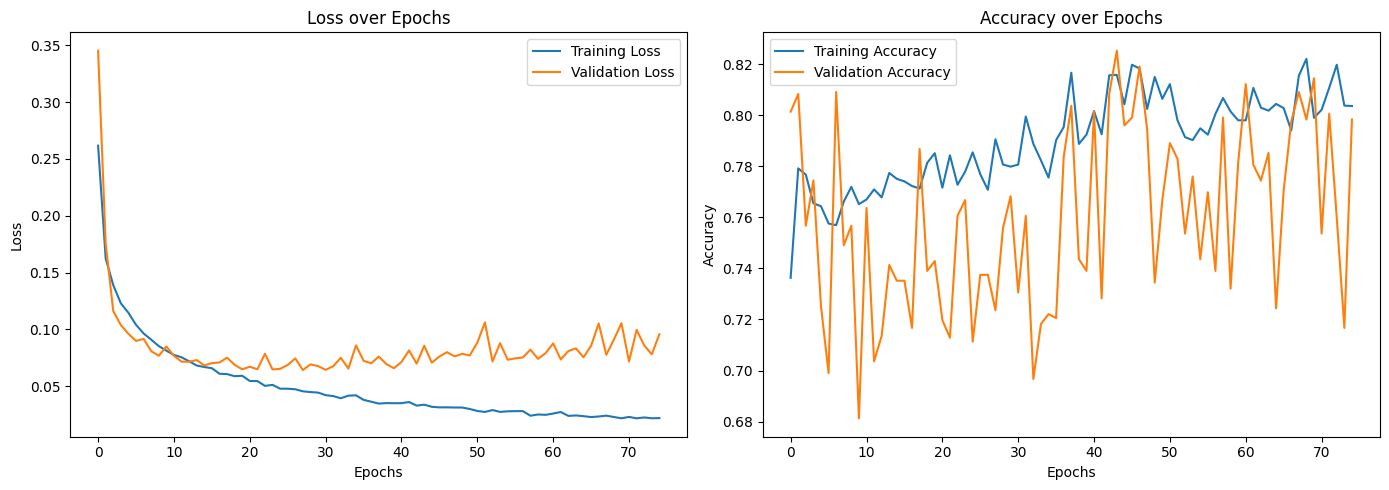

In [ ]:
# Plot training & validation loss and accuracy
plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Predict on test data
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int)  # threshold at 0.5

# Get list of driver names (from your topics list)
driver_names = topics

# Print classification report
print("\n--- Multi-Label Classification Report ---")
print(classification_report(y_test, y_pred, target_names=driver_names))

# Print ROC-AUC (Receiver Operating Charcteristic - Area Under Curve) scores
try:
    print("\n--- ROC-AUC Scores ---")
    roc_auc = roc_auc_score(y_test, y_pred_probs, average=None)
    for idx, score in enumerate(roc_auc):
        print(f"{driver_names[idx]}: {score:.4f}")
except ValueError:
    print("ROC AUC could not be calculated. (Need both positive and negative samples per label)")

# Multilabel Confusion Matrix
print("\n--- Multi-Label Confusion Matrices ---")
mcm = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrix per driver
for idx, matrix in enumerate(mcm):
    print(f"\nDriver: {driver_names[idx]}")
    print(matrix)


41/41 [==============================] - 2s 29ms/step

--- Multi-Label Classification Report ---
                     precision    recall  f1-score   support

   Customer Service       0.97      0.97      0.97      1003
            Digital       0.86      0.66      0.75       120
  Online Experience       0.99      0.97      0.98       105
 Outages and Faults       1.00      0.94      0.97       301
            Process       0.73      0.68      0.71        60
         Reputation       1.00      0.83      0.91         6
     Sustainability       0.00      0.00      0.00         1
              Trust       0.95      0.48      0.64        87
    Value for Money       0.97      0.98      0.98       310
Vulnerability & FDV       1.00      0.20      0.33        10

          micro avg       0.97      0.91      0.94      2003
          macro avg       0.85      0.67      0.72      2003
       weighted avg       0.96      0.91      0.93      2003
        samples avg       0.97      0.94      

/databricks/python/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/root/.ipykernel/4993/command-5419691576319607-57760455:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(topics))


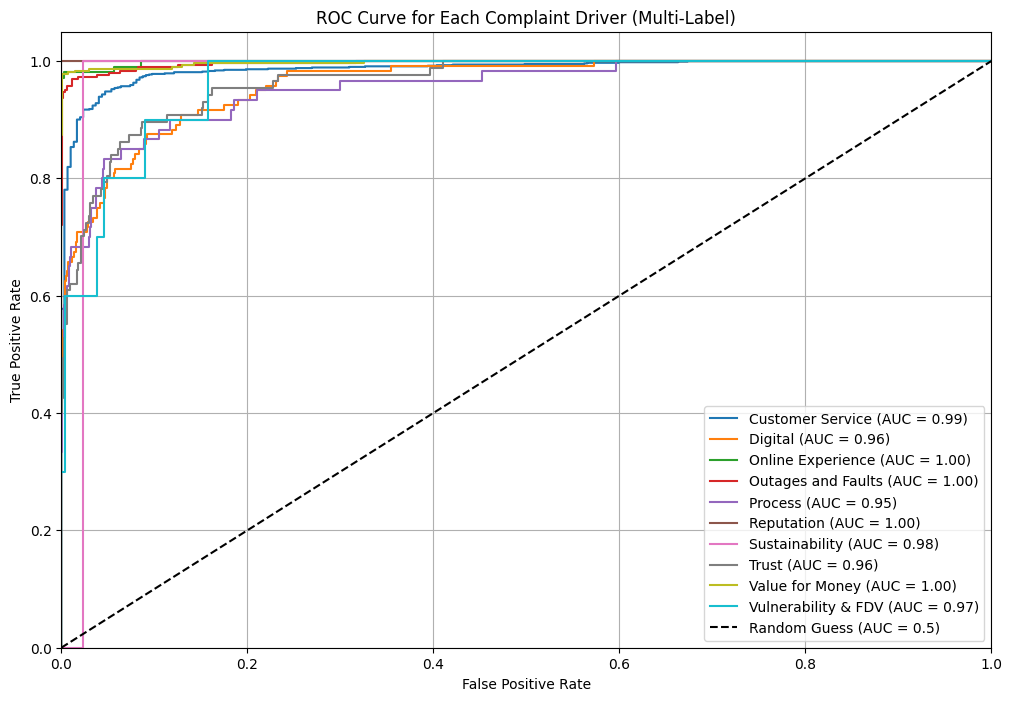

In [ ]:
# Threshold is not applied here - keep raw probabilities

# Create figure
plt.figure(figsize=(12, 8))

# Store TPR, FPR for each class
tpr_dict = {}
fpr_dict = {}

# Colors for ROC curves
colors = plt.cm.get_cmap('tab10', len(topics))

# For each class (topic)
for idx, topic in enumerate(topics):
    fpr, tpr, _ = roc_curve(y_test[:, idx], y_pred_probs[:, idx])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors(idx), label=f'{topic} (AUC = {roc_auc:.2f})')

    # Save TPR/FPR for later
    tpr_dict[topic] = tpr
    fpr_dict[topic] = fpr

# Plot random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Complaint Driver (Multi-Label)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/databricks/python/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/databricks/python/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


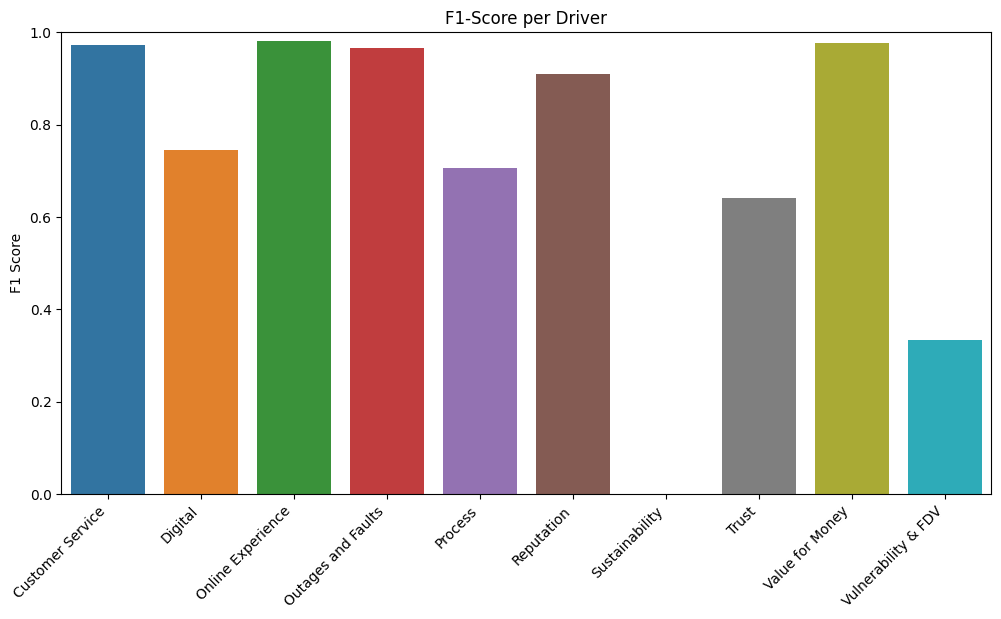

In [ ]:
report_dict = classification_report(y_test, y_pred, target_names=driver_names, output_dict=True)
f1_scores = [report_dict[driver]['f1-score'] for driver in driver_names]

plt.figure(figsize=(12,6))
sns.barplot(x=driver_names, y=f1_scores)
plt.title("F1-Score per Driver")
plt.xticks(rotation=45, ha='right')
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

In [ ]:
def himari_preprocess(text):
    """
    Preprocess customer comment according to HIMARI standards:
    - Lowercase
    - Remove PII
    - Remove stopwords
    - Add special tokens
    """
    text = text.lower().strip()
    text = scrubadub.clean(text)
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words]
    cleaned_text = " ".join(filtered_tokens)
    final_text = "<start> " + cleaned_text + " <end>"
    return final_text

def predict_drivers_from_comment(raw_comment, threshold=0.5):
    """
    Preprocess and predict drivers from a raw customer comment.
    """
    # Preprocess
    cleaned_comment = himari_preprocess(raw_comment)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_comment])
    padded = pad_sequences(sequence, maxlen=200, padding='post')

    # Predict
    probabilities = model.predict(padded)[0]

    # Interpret results
    predicted_drivers = []
    topics = [
                'Customer Service',
                'Digital',
                'Online Experience',
                'Outages and Faults',
                'Process',
                'Reputation',
                'Sustainability',
                'Trust',
                'Value for Money',
                'Vulnerability & FDV'
            ]
    
    for idx, prob in enumerate(probabilities):
        if prob >= threshold:
            predicted_drivers.append((topics[idx], round(prob, 3)))

    # Sort by probability (optional)
    predicted_drivers = sorted(predicted_drivers, key=lambda x: x[1], reverse=True)

    return predicted_drivers, cleaned_comment

input_text = """
                You sent me a reminder notice telling me I haven't paid my most Recent Bill.
                I fact I had paid it earlier yet you tell me your records indicate that I didn't pay.
                As well as having exorbitant and obscene charges / bills we need to put up with a lowering of the quality of service also?
                Get your house in order. My bank statement tell me my house is order!
             """

drivers, cleaned = predict_drivers_from_comment(input_text)

print(f"\nPreprocessed Comment: {cleaned}")
if drivers:
    print("Predicted Drivers:")
    for driver, score in drivers:
        print(f" - {driver} (Confidence: {score})")
else:
    print("No drivers detected confidently.")


1/1 [==============================] - 1s 656ms/step

Preprocessed Comment: <start> sent reminder notice telling paid recent bill. fact paid earlier yet tell records indicate pay. well exorbitant obscene charges / bills need put lowering quality service also? get house order. bank statement tell house order! <end>
Predicted Drivers:
 - Value for Money (Confidence: 1.0)
